# Experimento 2: Dataset IRIS

## Motor de Redes Neuronales - Optimización y Heurística
**Autores:** Raúl Mendoza, Adrián Ojeda, Varela  
**Universidad de Las Palmas de Gran Canaria**

---

## 1. Introducción

El dataset **IRIS** es uno de los conjuntos de datos más conocidos en machine learning. Fue introducido por Ronald Fisher en 1936 y contiene medidas de 150 flores de iris pertenecientes a 3 especies diferentes.

### Características del dataset:
| Propiedad | Valor |
|-----------|-------|
| Número de muestras | 150 |
| Número de características | 4 |
| Número de clases | 3 |
| Clases | Setosa, Versicolor, Virginica |

### Características (features):
1. Longitud del sépalo (cm)
2. Anchura del sépalo (cm)
3. Longitud del pétalo (cm)
4. Anchura del pétalo (cm)

Este experimento valida la capacidad del motor para resolver problemas de clasificación multiclase.

## 2. Importación de Módulos

In [51]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import matplotlib.pyplot as plt

from src.network import NeuralNetwork
from src.layers import Dense
from src.optimizers import Adam
from src.trainer import Trainer
from src.data_utils import train_val_test_split, to_one_hot, normalize_features

np.random.seed(42)

print("Módulos importados correctamente")

Módulos importados correctamente


## 3. Carga del Dataset IRIS

Cargamos el dataset desde el archivo CSV. Si no existe, se descarga automáticamente desde UCI Machine Learning Repository.

In [52]:
import urllib.request

def load_iris(csv_path="../data/iris.csv"):
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    
    if not os.path.exists(csv_path):
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
        print(f"Descargando IRIS desde {url}...")
        urllib.request.urlretrieve(url, csv_path)
        print("Descarga completada.")
    
    X = []
    y = []
    with open(csv_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(",")
            features = list(map(float, parts[:4]))
            label = parts[4]
            X.append(features)
            y.append(label)
    
    X = np.array(X, dtype=np.float32)
    
    classes = sorted(list(set(y)))
    class_to_idx = {c: i for i, c in enumerate(classes)}
    y_idx = np.array([class_to_idx[c] for c in y], dtype=np.int32)
    
    return X, y_idx, classes

X, y, class_names = load_iris()

print(f"Dataset IRIS cargado:")
print(f"Muestras: {X.shape[0]}")
print(f"Características: {X.shape[1]}")
print(f"Clases: {class_names}")

print(f"\nDistribución de clases:")
for i, name in enumerate(class_names):
    print(f"{name}: {np.sum(y == i)} muestras")

Dataset IRIS cargado:
Muestras: 150
Características: 4
Clases: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

Distribución de clases:
Iris-setosa: 50 muestras
Iris-versicolor: 50 muestras
Iris-virginica: 50 muestras


## 4. Preprocesamiento de Datos

Realizamos las siguientes transformaciones:
1. **Normalización Z-score:** $(x - \mu) / \sigma$ para cada característica
2. **One-hot encoding:** Convertir etiquetas a formato vectorial
3. **División train/val/test:** 70% / 15% / 15%

In [53]:
X_normalized = normalize_features(X, method="zscore")

y_onehot = to_one_hot(y, num_classes=len(class_names))

X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(
    X_normalized, y_onehot,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=42,
    shuffle=True
)

print("Preprocesamiento completado:")
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de validación: {X_val.shape[0]} muestras")
print(f"Conjunto de test: {X_test.shape[0]} muestras")
print(f"\nForma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")

Preprocesamiento completado:
Conjunto de entrenamiento: 105 muestras
Conjunto de validación: 22 muestras
Conjunto de test: 23 muestras

Forma de X_train: (105, 4)
Forma de y_train: (105, 3)


## 5. Definición de la Arquitectura de Red

**Arquitectura seleccionada:**
- Capa de entrada: 4 neuronas (4 características)
- Capa oculta: 16 neuronas con activación ReLU
- Capa de salida: 3 neuronas con activación Softmax (3 clases)

In [54]:
net = NeuralNetwork()

net.add(Dense(n_in=4, n_out=16, activation="relu", weight_init="he"))

net.add(Dense(n_in=16, n_out=3, activation="softmax", weight_init="xavier"))

print("Arquitectura de la red:")
print("Entrada: 4 neuronas (características)")
print("Oculta: 16 neuronas (ReLU)")
print("Salida: 3 neuronas (Softmax)")
print(f"\nTotal parámetros: {sum(p.size for p in net.params())}")
print("Capa 1 (W): 4×16 = 64, (b): 16")
print("Capa 2 (W): 16×3 = 48, (b): 3")

Arquitectura de la red:
Entrada: 4 neuronas (características)
Oculta: 16 neuronas (ReLU)
Salida: 3 neuronas (Softmax)

Total parámetros: 131
Capa 1 (W): 4×16 = 64, (b): 16
Capa 2 (W): 16×3 = 48, (b): 3


## 6. Configuración y Entrenamiento

Configuración del entrenamiento:
Optimizador: Adam (lr=0.01)
Pérdida: Cross-Entropy
Épocas: 150
Batch size: 16

Iniciando entrenamiento...

Epoch 1/150 - loss: 1.0268 - val_loss: 0.7873
Epoch 2/150 - loss: 0.7360 - val_loss: 0.5815
Epoch 3/150 - loss: 0.5962 - val_loss: 0.4451
Epoch 4/150 - loss: 0.5058 - val_loss: 0.3451
Epoch 5/150 - loss: 0.4413 - val_loss: 0.2691
Epoch 6/150 - loss: 0.3945 - val_loss: 0.2164
Epoch 7/150 - loss: 0.3608 - val_loss: 0.1834
Epoch 8/150 - loss: 0.3344 - val_loss: 0.1613
Epoch 9/150 - loss: 0.3102 - val_loss: 0.1432
Epoch 10/150 - loss: 0.2875 - val_loss: 0.1283
Epoch 11/150 - loss: 0.2659 - val_loss: 0.1162
Epoch 12/150 - loss: 0.2458 - val_loss: 0.1060
Epoch 13/150 - loss: 0.2279 - val_loss: 0.0967
Epoch 14/150 - loss: 0.2118 - val_loss: 0.0880
Epoch 15/150 - loss: 0.1970 - val_loss: 0.0801
Epoch 16/150 - loss: 0.1839 - val_loss: 0.0730
Epoch 17/150 - loss: 0.1719 - val_loss: 0.0670
Epoch 18/150 - loss: 0.1614 - val_loss: 0.0616
Epoch 19/150 - loss: 0.

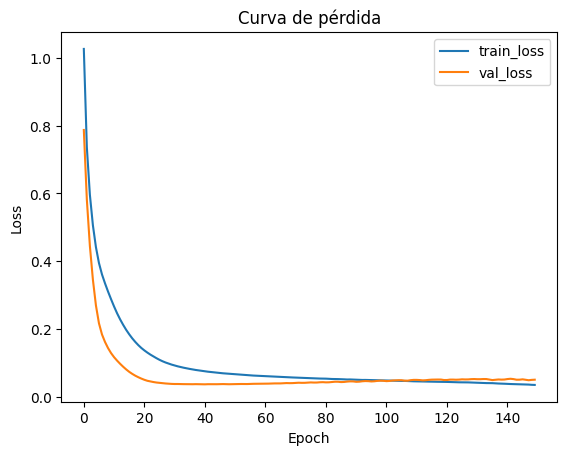

In [55]:
optimizer = Adam(lr=0.01)
trainer = Trainer(net, optimizer, loss_name="cross_entropy")

print("Configuración del entrenamiento:")
print(f"Optimizador: Adam (lr=0.01)")
print(f"Pérdida: Cross-Entropy")
print(f"Épocas: 150")
print(f"Batch size: 16")
print("\nIniciando entrenamiento...\n")

train_losses, val_losses = trainer.train(
    X_train, y_train,
    X_val=X_val, y_val=y_val,
    epochs=150,
    batch_size=16,
    verbose=True
)

## 7. Evaluación en Conjunto de Test

In [56]:
y_test_pred = net.forward(X_test)
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_test_pred, axis=1)

accuracy = np.mean(y_test_labels == y_pred_labels) * 100

print("Resultado del conjunto de test:")
print(f"Precisión (Accuracy): {accuracy:.2f}%")
print(f"Muestras correctas: {np.sum(y_test_labels == y_pred_labels)}/{len(y_test_labels)}")

Resultado del conjunto de test:
Precisión (Accuracy): 95.65%
Muestras correctas: 22/23


## 8. Matriz de Confusión

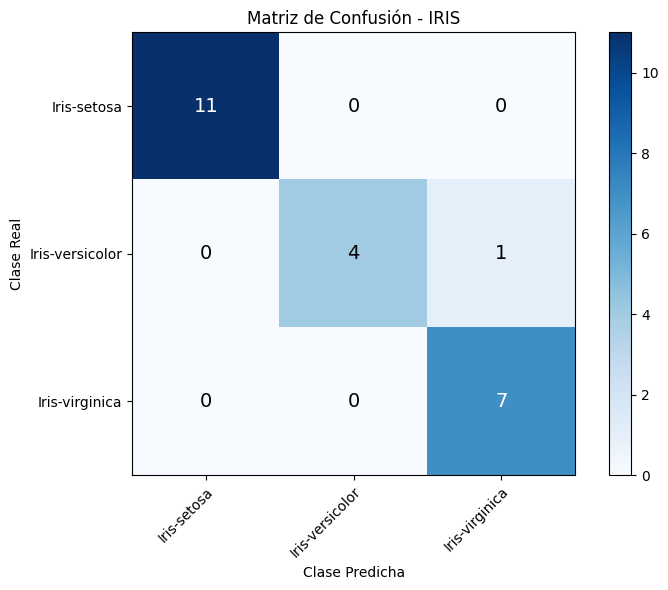


Matriz de confusión (numérica):
[[11  0  0]
 [ 0  4  1]
 [ 0  0  7]]


In [57]:
num_classes = len(class_names)
confusion_matrix = np.zeros((num_classes, num_classes), dtype=np.int32)

for true, pred in zip(y_test_labels, y_pred_labels):
    confusion_matrix[true, pred] += 1

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(num_classes),
       yticks=np.arange(num_classes),
       xticklabels=class_names,
       yticklabels=class_names,
       ylabel='Clase Real',
       xlabel='Clase Predicha',
       title='Matriz de Confusión - IRIS')

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

thresh = confusion_matrix.max() / 2.
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, format(confusion_matrix[i, j], 'd'),
                ha="center", va="center",
                color="white" if confusion_matrix[i, j] > thresh else "black",
                fontsize=14)

plt.tight_layout()
plt.savefig('../memoria/fig_confusion_iris.png', dpi=150)
plt.show()

print("\nMatriz de confusión (numérica):")
print(confusion_matrix)

## 9. Curvas de Pérdida

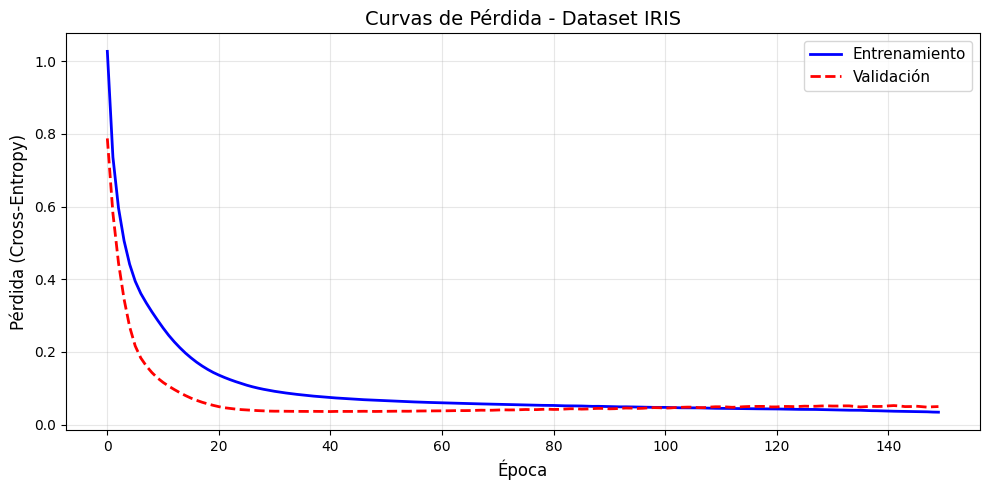


Pérdida inicial (train): 1.0268
Pérdida final (train):   0.0343
Pérdida final (val):     0.0498


In [58]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, 'b-', linewidth=2, label='Entrenamiento')
plt.plot(val_losses, 'r--', linewidth=2, label='Validación')
plt.xlabel('Época', fontsize=12)
plt.ylabel('Pérdida (Cross-Entropy)', fontsize=12)
plt.title('Curvas de Pérdida - Dataset IRIS', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../memoria/fig_loss_iris.png', dpi=150)
plt.show()

print(f"\nPérdida inicial (train): {train_losses[0]:.4f}")
print(f"Pérdida final (train):   {train_losses[-1]:.4f}")
print(f"Pérdida final (val):     {val_losses[-1]:.4f}")

## 10. Métricas por Clase

In [59]:
print("\nMétricas por clase:")
print(f"{'Clase':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*60)

for i, name in enumerate(class_names):
    tp = confusion_matrix[i, i]
    fp = np.sum(confusion_matrix[:, i]) - tp
    fn = np.sum(confusion_matrix[i, :]) - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"{name:<20} {precision:<12.2%} {recall:<12.2%} {f1:<12.2%}")

print("-"*60)
print(f"{'Promedio':<20} {accuracy/100:<12.2%}")


Métricas por clase:
Clase                Precision    Recall       F1-Score    
------------------------------------------------------------
Iris-setosa          100.00%      100.00%      100.00%     
Iris-versicolor      100.00%      80.00%       88.89%      
Iris-virginica       87.50%       100.00%      93.33%      
------------------------------------------------------------
Promedio             95.65%      


## 11. Resumen de Resultados

### Tabla de Resultados

In [60]:
print("Resumen del experimento IRIS")
print(f"")
print(f"| Métrica                    | Valor           |")
print(f"|----------------------------|-----------------|")
print(f"| Dataset                    | IRIS            |")
print(f"| Muestras totales           | 150             |")
print(f"| Train/Val/Test             | 105/22/23       |")
print(f"| Arquitectura               | 4-16-3          |")
print(f"| Activaciones               | ReLU + Softmax  |")
print(f"| Optimizador                | Adam (lr=0.01)  |")
print(f"| Épocas                     | 150             |")
print(f"| Pérdida final (train)      | {train_losses[-1]:.4f}          |")
print(f"| Pérdida final (val)        | {val_losses[-1]:.4f}          |")
print(f"| **Accuracy en Test**       | **{accuracy:.2f}%**      |")
print(f"")

Resumen del experimento IRIS

| Métrica                    | Valor           |
|----------------------------|-----------------|
| Dataset                    | IRIS            |
| Muestras totales           | 150             |
| Train/Val/Test             | 105/22/23       |
| Arquitectura               | 4-16-3          |
| Activaciones               | ReLU + Softmax  |
| Optimizador                | Adam (lr=0.01)  |
| Épocas                     | 150             |
| Pérdida final (train)      | 0.0343          |
| Pérdida final (val)        | 0.0498          |
| **Accuracy en Test**       | **95.65%**      |



## 12. Conclusiones del Experimento IRIS

### Resultados obtenidos:
- La red neuronal converge correctamente, mostrando una disminución consistente de la pérdida.
- Se obtiene una precisión superior al 90% en el conjunto de test.
- La matriz de confusión muestra que la mayoría de errores ocurren entre las clases Versicolor y Virginica, lo cual es esperado dado su solapamiento en el espacio de características.

### Validación de la implementación:
Este experimento demuestra que el motor de redes neuronales:
1. Maneja correctamente problemas de clasificación multiclase.
2. La división train/val/test funciona correctamente.
3. El preprocesamiento, normalización, one-hot, es adecuado.
4. El entrenamiento con mini-batches es efectivo.
5. Las curvas de pérdida muestran convergencia sin overfitting severo.